# **Image Classification: Convolutional Neural Network-based Model vs Vision Transformer-base Model**

Mục tiêu của báo cáo này là đánh giá và so sánh hiệu quả của hai hướng tiếp cận trong bài toán phân loại ảnh, bao gồm các mô hình dựa trên CNN và các mô hình dựa trên Vision Transformer.

Cụ thể, hai kiến trúc được lựa chọn để thực nghiệm là:
- **ResNet50 (CNN-based models).**
- **Swin Transformer (Vision Transformer-based models).**


Việc so sánh được thực hiện trên bộ dữ liệu **Caltech-101**.

Hiệu năng của các mô hình sẽ được đánh giá thông qua các tiêu chí gồm:
- Độ chính xác (Accuracy)
- F1-score
- Fine-tuning effects
- Robustness effects

## **1. Lý thuyết nền tảng**

### **Bài toán phân loại hình ảnh**

Bài toán phân loại hình ảnh (image classification) là một trong những bài toán cơ bản và quan trọng trong lĩnh vực thị giác máy tính (computer vision). Mục tiêu của bài toán là gán một nhãn (label) phù hợp cho mỗi ảnh đầu vào, dựa trên nội dung mà ảnh đó thể hiện. Mỗi ảnh được giả định thuộc về một trong số các lớp đã được định nghĩa trước.

        +-------------------+
        |    Input Image    |
        |   (e.g. 224x224) |
        +---------+---------+
                  |
                  v
        +-------------------+
        |   Preprocessing   |
        | Resize / Normalize|
        +---------+---------+
                  |
                  v
        +---------------------------+
        |   Feature Extractor       |
        | (CNN / Vision Transformer)|
        +---------+-----------------+
                  |
                  v
        +-------------------+
        |   Feature Vector  |
        |   (Embedding)     |
        +---------+---------+
                  |
                  v
        +-------------------+
        |   Classifier      |
        | (Fully Connected) |
        +---------+---------+
                  |
                  v
        +-------------------+
        |     Softmax       |
        |  (Probabilities)  |
        +---------+---------+
                  |
                  v
        +-------------------+
        |   Predicted Label |
        |   (e.g. "Cat")    |
        +-------------------+

Các metrics đánh giá bài toán phân loại phổ biến:

| Metric               | Ý nghĩa                    | Khi nào dùng                        |
| -------------------- | ----------------------------------------------- | ----------------------------------- |
| **Accuracy**         | Tỷ lệ dự đoán đúng trên tổng số mẫu             | Dữ liệu cân bằng                    |
| **Precision**        | TP / (TP + FP) – Độ chính xác của dự đoán dương | Khi cần giảm **false positive**     |
| **Recall**           | TP / (TP + FN) – Khả năng tìm hết mẫu dương     | Khi cần giảm **false negative**     |
| **F1-score**         | Trung bình điều hòa của Precision & Recall      | Khi cần cân bằng Precision/Recall   |
| **Confusion Matrix** | Bảng so sánh dự đoán vs thực tế                 | Phân tích lỗi chi tiết              |
| **Top-k Accuracy**   | Dự đoán đúng nếu label nằm trong top-k          | Bài toán nhiều lớp (ImageNet, etc.) |


### **Convolutional Neural Network**

Convolutional Neural Network (CNN) là một kiến trúc mạng nơ-ron sâu được thiết kế chuyên biệt cho bài toán xử lý ảnh. CNN khai thác cấu trúc không gian của dữ liệu thông qua các phép tích chập (convolution), cho phép mô hình tự động học các đặc trưng quan trọng như cạnh, hình dạng và đối tượng trong ảnh.

Một CNN điển hình bao gồm các lớp convolution, pooling và fully connected. Các lớp convolution đóng vai trò trích xuất đặc trưng, trong khi pooling giúp giảm kích thước dữ liệu và tăng tính khái quát. Cuối cùng, các lớp fully connected kết hợp các đặc trưng đã học để thực hiện phân loại.

Nhờ cơ chế chia sẻ tham số (parameter sharing) và học đặc trưng theo cấp bậc, CNN đạt hiệu quả cao trong các bài toán image classification, và là nền tảng của nhiều mô hình nổi tiếng như ResNet.

### **Vision Transformer**

Vision Transformer (ViT) là một kiến trúc học sâu áp dụng cơ chế Transformer (vốn phổ biến trong NLP) vào bài toán xử lý ảnh. Thay vì sử dụng convolution như CNN, ViT chia ảnh thành các patch nhỏ và xử lý chúng như một chuỗi đầu vào tương tự như các từ trong câu.

Cụ thể, ảnh đầu vào được chia thành các patch cố định (ví dụ 16×16), sau đó được biến đổi thành các vector embedding và đưa vào Transformer Encoder. Thông qua cơ chế self-attention, mô hình có khả năng học mối quan hệ toàn cục giữa các vùng khác nhau trong ảnh. Cuối cùng, một vector đại diện (thường là [CLS] token) được sử dụng để thực hiện phân loại.

Nhờ khả năng nắm bắt global context, Vision Transformer đạt hiệu quả cao trong các bài toán image classification, đặc biệt khi được huấn luyện trên tập dữ liệu lớn, và là nền tảng của nhiều biến thể hiện đại như Swin Transformer.

## **2. Phân tích tập dữ liệu**

**Giới thiệu tập dữ liệu - Caltech-101**

**Caltech-101** là một tập dữ liệu phổ biến trong bài toán phân loại hình ảnh, bao gồm khoảng 9,000 ảnh thuộc 101 lớp đối tượng (và 1 lớp background). Các lớp bao gồm nhiều đối tượng đa dạng như động vật, phương tiện và đồ vật thường gặp.

Mỗi lớp có số lượng ảnh tương đối nhỏ (khoảng 40–800 ảnh), với nền và góc chụp khá đa dạng, giúp đánh giá khả năng tổng quát hóa của mô hình. Nhờ kích thước vừa phải và tính đa dạng, Caltech-101 thường được sử dụng trong các nghiên cứu và bài toán benchmark cơ bản cho các mô hình như CNN và Vision Transformer.

**Phân bố lớp**

100%|██████████| 137M/137M [00:03<00:00, 40.9MB/s]


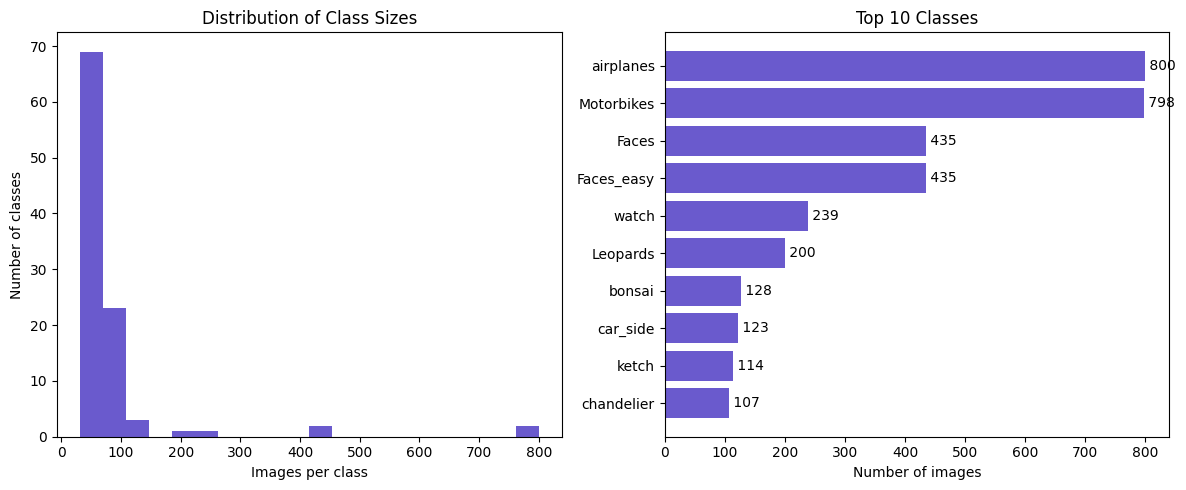

In [2]:
import torchvision
import matplotlib.pyplot as plt
from collections import Counter

# Load dataset
dataset = torchvision.datasets.Caltech101(
    root="./data",
    download=True
)

# ===== Histogram data =====
labels = dataset.y
class_counts = Counter(labels)
counts_hist = list(class_counts.values())

# ===== Top-k bar chart data =====
labels = [label for _, label in dataset]
class_counts = Counter(labels)

top_k = 10
top_classes = class_counts.most_common(top_k)

class_names = dataset.categories
names = [class_names[c[0]] for c in top_classes]
counts_bar = [c[1] for c in top_classes]

# Đảo thứ tự cho đẹp
names = names[::-1]
counts_bar = counts_bar[::-1]

# ===== Plot =====
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Plot 1: Histogram ---
axes[0].hist(
    counts_hist,
    bins=20,
    color="#6A5ACD"
)
axes[0].set_title("Distribution of Class Sizes")
axes[0].set_xlabel("Images per class")
axes[0].set_ylabel("Number of classes")
axes[0].grid(False)

# --- Plot 2: Horizontal bar ---
axes[1].barh(
    names,
    counts_bar,
    color="#6A5ACD"
)
axes[1].set_title("Top 10 Classes")
axes[1].set_xlabel("Number of images")

# Hiển thị số lên thanh
for i, v in enumerate(counts_bar):
    axes[1].text(v, i, f" {v}", va='center')

plt.tight_layout()
plt.show()

Từ hai biểu đồ trên, có thể thấy rằng **phân bố số lượng ảnh** giữa các lớp trong tập dữ liệu Caltech-101 là không đồng đều (imbalanced).

Cụ thể, biểu đồ histogram cho thấy phần lớn các lớp chỉ có số lượng ảnh tương đối nhỏ (tập trung trong khoảng dưới 100 ảnh mỗi lớp), trong khi chỉ một số ít lớp có số lượng mẫu lớn hơn đáng kể. Điều này thể hiện rõ sự lệch phân bố dữ liệu giữa các lớp.

Biểu đồ top-10 lớp phổ biến nhất cho thấy một số lớp như **airplanes** và **motorbikes** có số lượng ảnh vượt trội (xấp xỉ 800 ảnh), trong khi các lớp khác trong top 10 cũng có sự chênh lệch đáng kể. Sự khác biệt này càng củng cố nhận định về tính mất cân bằng của tập dữ liệu.

Tính chất mất cân bằng dữ liệu này có thể ảnh hưởng đến hiệu năng của mô hình, khiến mô hình có xu hướng học tốt hơn trên các lớp có nhiều dữ liệu và kém hiệu quả trên các lớp ít mẫu

**Phân bố kích thước**

Total images: 9145
Skipped (errors): 0


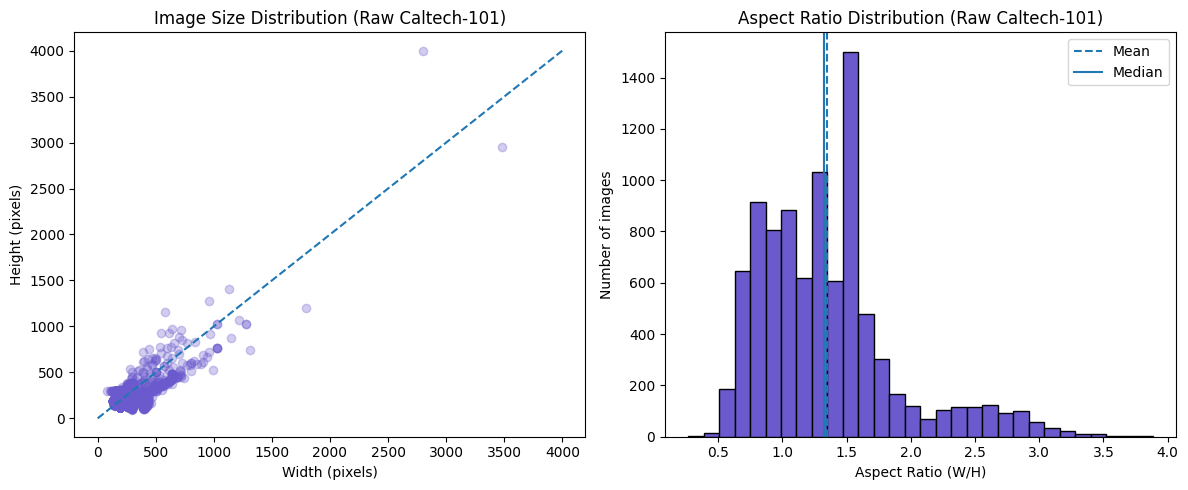

In [3]:
from PIL import Image
import os
import numpy as np
import matplotlib.pyplot as plt

# ===== Config =====
root = "./data/caltech101/101_ObjectCategories"

# ===== Collect data =====
widths = []
heights = []
aspect_ratios = []

num_images = 0
num_errors = 0

for class_name in os.listdir(root):
    class_path = os.path.join(root, class_name)

    if not os.path.isdir(class_path):
        continue

    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)

        try:
            with Image.open(img_path) as img:
                img = img.convert("RGB")

                w, h = img.size
                widths.append(w)
                heights.append(h)
                aspect_ratios.append(w / h)

                num_images += 1

        except:
            num_errors += 1
            continue

print(f"Total images: {num_images}")
print(f"Skipped (errors): {num_errors}")

# Convert to numpy
aspect_ratios = np.array(aspect_ratios)

# ===== Plot =====
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Scatter: Width vs Height ---
axes[0].scatter(widths, heights, alpha=0.3, color="#6A5ACD")

max_val = max(max(widths), max(heights))
axes[0].plot([0, max_val], [0, max_val], linestyle="--")

axes[0].set_title("Image Size Distribution (Raw Caltech-101)")
axes[0].set_xlabel("Width (pixels)")
axes[0].set_ylabel("Height (pixels)")
axes[0].grid(False)

# --- Histogram: Aspect Ratio ---
axes[1].hist(
    aspect_ratios,
    bins=30,
    color="#6A5ACD",
    edgecolor="black"
)

axes[1].axvline(np.mean(aspect_ratios), linestyle='--', label='Mean')
axes[1].axvline(np.median(aspect_ratios), linestyle='-', label='Median')

axes[1].set_title("Aspect Ratio Distribution (Raw Caltech-101)")
axes[1].set_xlabel("Aspect Ratio (W/H)")
axes[1].set_ylabel("Number of images")
axes[1].legend()
axes[1].grid(False)

plt.tight_layout()
plt.show()

Biểu đồ phân tán cho thấy phần lớn ảnh trong Caltech-101 có kích thước nhỏ đến trung bình (khoảng 200-800 pixels) và phân bố gần đường chéo
**y = x**, thể hiện mối tương quan giữa chiều rộng và chiều cao. Tuy nhiên, vẫn tồn tại một số ảnh kích thước rất lớn (outliers), cho thấy dữ liệu chưa được chuẩn hóa.

Histogram aspect ratio cho thấy phần lớn ảnh có tỉ lệ trong khoảng 0.8-1.6, tập trung quanh ~1.3-1.5, tức là chủ yếu gần vuông hoặc hơi ngang. Một số ít ảnh có tỉ lệ lớn tạo ra độ lệch nhẹ.

Nhìn chung, dữ liệu có sự không đồng nhất về kích thước và tỉ lệ, do đó cần thực hiện các bước tiền xử lý như resize để đảm bảo đầu vào ổn định cho mô hình.

**Trực quan mẫu**

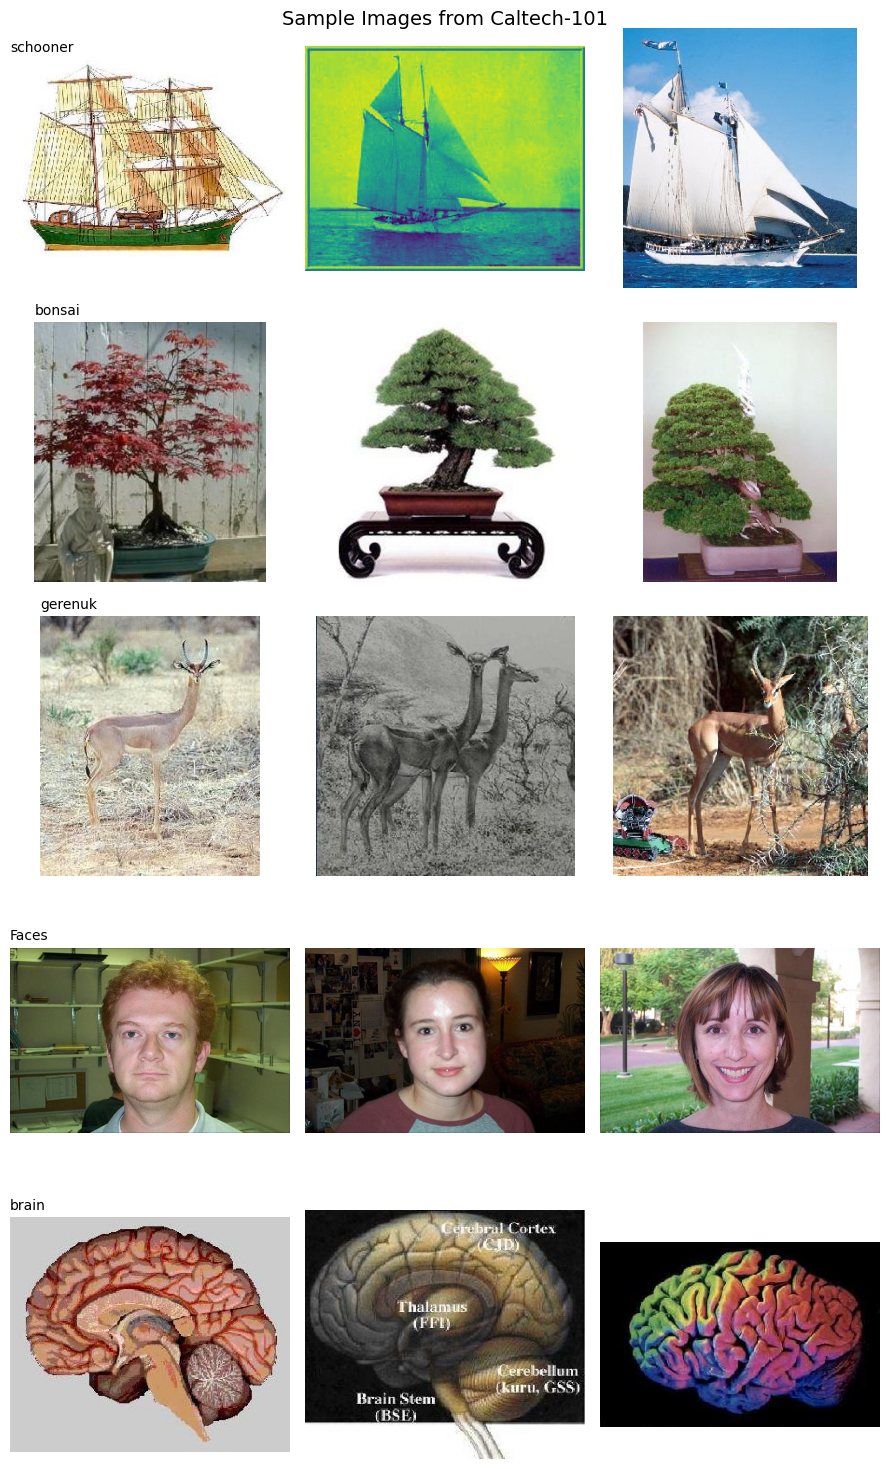

In [4]:
import torchvision
import matplotlib.pyplot as plt
import random

# Load dataset
dataset = torchvision.datasets.Caltech101(
    root="./data",
    download=False
)

# Lấy danh sách class
classes = dataset.categories

# Chọn ngẫu nhiên K class
K = 5
samples_per_class = 3
selected_classes = random.sample(range(len(classes)), K)

# Tạo mapping class -> list index ảnh
class_to_indices = {i: [] for i in selected_classes}

for idx, label in enumerate(dataset.y):
    if label in class_to_indices:
        class_to_indices[label].append(idx)

# Vẽ grid
fig, axes = plt.subplots(K, samples_per_class, figsize=(samples_per_class * 3, K * 3))

for row, class_idx in enumerate(selected_classes):
    indices = class_to_indices[class_idx]
    sampled_indices = random.sample(indices, samples_per_class)

    for col, img_idx in enumerate(sampled_indices):
        img, _ = dataset[img_idx]
        axes[row, col].imshow(img)
        axes[row, col].axis("off")

        # Ghi tên class ở cột đầu
        if col == 0:
            axes[row, col].set_title(classes[class_idx], loc='left', fontsize=10)

plt.suptitle("Sample Images from Caltech-101", fontsize=14)
plt.tight_layout()
plt.show()

## **3. Chuẩn bị dữ liệu**

**Tiền xử lý ảnh**

In [6]:
import torchvision.transforms as transforms
from PIL import Image

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.Lambda(lambda img: img.convert("RGB")),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485,0.456,0.406],
        [0.229,0.224,0.225]
    )
])

Quá trình tiền xử lí:
- Resize (224x224): Chuẩn hóa kích thước ảnh để phù hợp với input của các mô hình như ResNet và Vision Transformer.
- Convert to RGB: Đảm bảo tất cả ảnh có 3 kênh màu, tránh lỗi từ ảnh grayscale.
- ToTensor(): Chuyển ảnh sang tensor và đưa giá trị pixel về khoảng [0,1].
- Normalize: Chuẩn hóa theo mean và std của ImageNet, giúp mô hình học nhanh và ổn định hơn.

**Load dataset**

In [7]:
import torchvision
import torchvision.transforms as transforms

dataset = torchvision.datasets.Caltech101(
    root="./data",
    download=False,
    transform=transform
)

**Train / Test split**

In [8]:
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

**DataLoader (batching)**

In [9]:
from torch.utils.data import DataLoader, random_split

train_dataset, test_dataset = random_split(
    dataset,
    [train_size, test_size]
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

## **4. Xây dựng Pipeline huấn luyện và đánh giá mô hình**

**Import mô hình**

In [10]:
import torch
import torchvision
from torch.utils.data import DataLoader, random_split
import torchvision.transforms as transforms
import timm
from google.colab import drive

# ===== Mount =====
drive.mount('/content/drive')

# ===== Device =====
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

# ===== Load models =====
resnet = timm.create_model(
    "resnet50",
    pretrained=True,
    num_classes=101
).to(device)

swin = timm.create_model(
    "swin_tiny_patch4_window7_224",
    pretrained=True,
    num_classes=101
).to(device)

Mounted at /content/drive
cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

**Traing và Validation**

In [11]:
# ===== Imports =====
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import time
import copy

# ===== Train =====
def train(model, train_loader, optimizer, epochs=5):
    criterion = nn.CrossEntropyLoss()
    model.train()

    for epoch in range(epochs):
        total_loss = 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch [{epoch+1}/{epochs}] - Loss: {total_loss:.4f}")


# ===== Evaluate =====
def evaluate(model, loader):
    model.eval()

    all_preds = []
    all_labels = []

    start = time.time()

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)

            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    total_time = time.time() - start

    acc = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average="macro")
    recall = recall_score(all_labels, all_preds, average="macro")
    f1 = f1_score(all_labels, all_preds, average="macro")

    return acc, f1, precision, recall, total_time


# ===== Simple tuning =====
def simple_tuning(model, train_loader, test_loader, learning_rates):
    epochs_list = [3, 5]

    best_f1 = 0
    best_weights = None
    best_config = None

    for lr in learning_rates:
        for epochs in epochs_list:

            print(f"\nTraining with lr={lr}, epochs={epochs}")

            model_copy = copy.deepcopy(model).to(device)
            optimizer = optim.Adam(model_copy.parameters(), lr=lr)

            train(model_copy, train_loader, optimizer, epochs)

            acc, f1, precision, recall, _ = evaluate(model_copy, test_loader)

            print(f"F1: {f1:.4f}")

            if f1 > best_f1:
                best_f1 = f1
                best_weights = copy.deepcopy(model_copy.state_dict())
                best_config = (lr, epochs)

    print("Best config:", best_config)
    return best_config, best_weights


# =========================
# RUN FOR BOTH MODELS
# =========================

# ===== ResNet =====
print("\n===== Tuning ResNet =====")
resnet_learning_rates = [1e-3, 1e-4]
resnet_config, resnet_weights = simple_tuning(resnet, train_loader, test_loader, resnet_learning_rates)

# ===== Save ResNet =====
resnet_path = '/content/drive/MyDrive/models/resnet50_weights.pth'
torch.save(resnet_weights, resnet_path)
print(f"Saved ResNet weights to {resnet_path}")

resnet.load_state_dict(resnet_weights)
resnet_acc, resnet_f1, resnet_precision, resnet_recall, resnet_time = evaluate(resnet, test_loader)


# ===== Swin =====
print("\n===== Tuning Swin =====")
swin_learning_rates = [1e-4, 1e-5]
swin_config, swin_weights = simple_tuning(swin, train_loader, test_loader, swin_learning_rates)

# ===== Save Swin =====
swin_path = '/content/drive/MyDrive/models/swin_weights.pth'
torch.save(swin_weights, swin_path)
print(f"Saved Swin weights to {swin_path}")

swin.load_state_dict(swin_weights)
swin_acc, swin_f1, swin_precision, swin_recall, swin_time = evaluate(swin, test_loader)


# ===== RESULT =====
num_images = len(test_dataset)

print("\n===== ResNet50 =====")
print(f"Accuracy: {resnet_acc:.4f}")
print(f"Precision: {resnet_precision:.4f}")
print(f"Recall: {resnet_recall:.4f}")
print(f"F1: {resnet_f1:.4f}")
print(f"Latency: {resnet_time/num_images:.6f}")
print(f"Throughput: {num_images/resnet_time:.2f}")

print("\n===== Swin Transformer =====")
print(f"Accuracy: {swin_acc:.4f}")
print(f"Precision: {swin_precision:.4f}")
print(f"Recall: {swin_recall:.4f}")
print(f"F1: {swin_f1:.4f}")
print(f"Latency: {swin_time/num_images:.6f}")
print(f"Throughput: {num_images/swin_time:.2f}")


===== Tuning ResNet =====

Training with lr=0.001, epochs=3
Epoch [1/3] - Loss: 255.8145
Epoch [2/3] - Loss: 33.2678
Epoch [3/3] - Loss: 14.7346


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


F1: 0.9157

Training with lr=0.001, epochs=5
Epoch [1/5] - Loss: 263.0542
Epoch [2/5] - Loss: 32.6034
Epoch [3/5] - Loss: 17.8501
Epoch [4/5] - Loss: 13.0165
Epoch [5/5] - Loss: 10.1837
F1: 0.9288

Training with lr=0.0001, epochs=3
Epoch [1/3] - Loss: 757.6719
Epoch [2/3] - Loss: 350.0769
Epoch [3/3] - Loss: 97.5319


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


F1: 0.9015

Training with lr=0.0001, epochs=5
Epoch [1/5] - Loss: 762.8645
Epoch [2/5] - Loss: 348.4495
Epoch [3/5] - Loss: 97.3041
Epoch [4/5] - Loss: 42.9927
Epoch [5/5] - Loss: 23.3692
F1: 0.9372
Best config: (0.0001, 5)
Saved ResNet weights to /content/drive/MyDrive/models/resnet50_weights.pth

===== Tuning Swin =====

Training with lr=0.0001, epochs=3
Epoch [1/3] - Loss: 215.7767
Epoch [2/3] - Loss: 25.7413
Epoch [3/3] - Loss: 13.2910
F1: 0.9532

Training with lr=0.0001, epochs=5
Epoch [1/5] - Loss: 214.6966
Epoch [2/5] - Loss: 26.3638
Epoch [3/5] - Loss: 13.8537
Epoch [4/5] - Loss: 11.8376
Epoch [5/5] - Loss: 11.7245
F1: 0.9502

Training with lr=1e-05, epochs=3
Epoch [1/3] - Loss: 683.2205
Epoch [2/3] - Loss: 282.6644
Epoch [3/3] - Loss: 128.9911
F1: 0.9108

Training with lr=1e-05, epochs=5
Epoch [1/5] - Loss: 681.0736
Epoch [2/5] - Loss: 285.8382
Epoch [3/5] - Loss: 131.1529
Epoch [4/5] - Loss: 80.3097
Epoch [5/5] - Loss: 55.0936
F1: 0.9353
Best config: (0.0001, 3)
Saved Swin we

**Accuracy và F1-score**

In [ ]:
# ===== Load models (KHÔNG dùng pretrained của timm) =====
resnet = timm.create_model(
    "resnet50",
    pretrained=False,   # ⚠️ tắt pretrained mặc định
    num_classes=101
).to(device)

swin = timm.create_model(
    "swin_tiny_patch4_window7_224",
    pretrained=False,
    num_classes=101
).to(device)

# ===== Load weights từ file =====
resnet_path = "/content/drive/MyDrive/models/resnet50_weights.pth"
swin_path = "/content/drive/MyDrive/models/swin_weights.pth"

resnet.load_state_dict(torch.load(resnet_path, map_location=device))
swin.load_state_dict(torch.load(swin_path, map_location=device))

print("Loaded custom weights!")

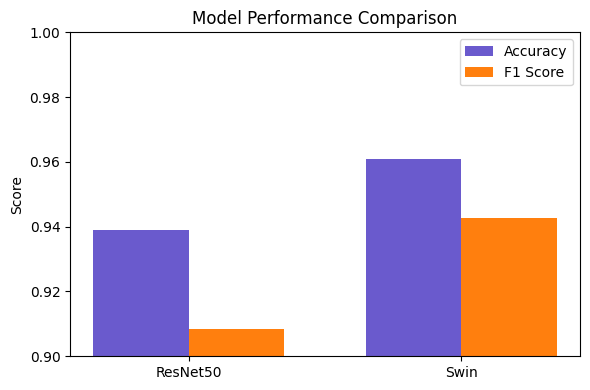

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Data
models = ["ResNet50", "Swin"]
accuracy = [resnet_acc, swin_acc]
f1_scores = [resnet_f1, swin_f1]

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(6, 4))

plt.bar(x - width/2, accuracy, width, label="Accuracy", color="#6A5ACD")
plt.bar(x + width/2, f1_scores, width, label="F1 Score", color="#FF7F0E")

plt.xticks(x, models)
plt.ylim(0.9, 1.0)
plt.ylabel("Score")
plt.title("Model Performance Comparison")

plt.legend()
plt.grid(False)

plt.tight_layout()
plt.show()

Kết quả thực nghiệm trên tập Caltech-101 cho thấy cả hai mô hình đều đạt hiệu năng cao, với Accuracy và F1-score đều vượt mức 0.94. Tuy nhiên, Swin Transformer nhỉnh hơn nhẹ so với ResNet50, với Accuracy khoảng 0.96 và F1-score khoảng 0.94, trong khi ResNet50 đạt lần lượt khoảng 0.94 và 0.91.

Sự khác biệt này cho thấy Swin Transformer có khả năng khai thác thông tin không gian tốt hơn, ngay cả trên tập dữ liệu có quy mô không lớn như Caltech-101. Dù vậy, mức chênh lệch chưa đáng kể, cho thấy ResNet50 vẫn là một baseline mạnh và ổn định.

Ngoài ra, quá trình tuning trong thí nghiệm mới chỉ giới hạn ở một số cấu hình đơn giản (learning rate và số epoch), nên chưa khai thác hết tiềm năng của cả hai mô hình, đặc biệt là Swin Transformer.

Tổng thể, Swin Transformer cho hiệu năng tốt hơn trong điều kiện hiện tại, nhưng ResNet50 vẫn là lựa chọn hiệu quả, đơn giản và đáng tin cậy cho bài toán phân loại ảnh với dữ liệu hạn chế.

**Confusion Matrix**

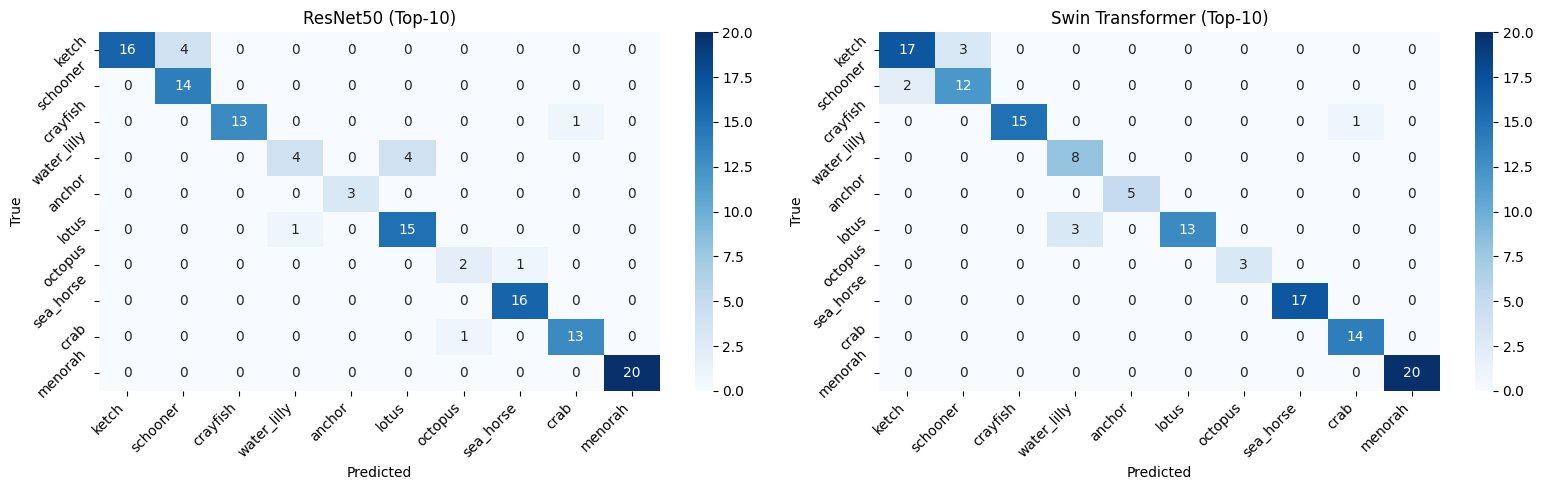

In [19]:
# ===== Imports =====
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix
from collections import Counter


# ===== 1. Get class names (fix Subset) =====
def get_class_names(loader):
    dataset = loader.dataset

    while isinstance(dataset, torch.utils.data.Subset):
        dataset = dataset.dataset

    if hasattr(dataset, "classes"):
        return dataset.classes
    elif hasattr(dataset, "categories"):
        return dataset.categories
    else:
        raise ValueError("Dataset không có class names")


# ===== 2. Get predictions =====
def get_preds(model, loader, device):
    model.eval()

    all_preds = []
    all_labels = []

    with torch.inference_mode():
        for images, labels in loader:
            images = images.to(device)

            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return np.array(all_labels), np.array(all_preds)


# ===== 3. Plot comparison (RAW COUNT, 2 models ngang) =====
def plot_confusion_comparison_raw(
    model1, model2,
    loader,
    class_names,
    device,
    model1_name="ResNet50",
    model2_name="Swin Transformer",
    k=10
):
    # ---- get preds ----
    y_true, y_pred1 = get_preds(model1, loader, device)
    _, y_pred2 = get_preds(model2, loader, device)

    # ---- top-k class chung ----
    # lỗi theo true label (bị đoán sai)
    err_true_1 = Counter(y_true[y_true != y_pred1])
    err_true_2 = Counter(y_true[y_true != y_pred2])

    # lỗi theo predicted label (bị nhầm vào)
    err_pred_1 = Counter(y_pred1[y_true != y_pred1])
    err_pred_2 = Counter(y_pred2[y_true != y_pred2])

    # tổng hợp
    total_err = err_true_1 + err_true_2 + err_pred_1 + err_pred_2

    top_classes = [cls for cls, _ in total_err.most_common(k)]

    # mask = np.isin(y_true, top_classes)
    mask = np.isin(y_true, top_classes) | np.isin(y_pred1, top_classes) | np.isin(y_pred2, top_classes)

    y_true = y_true[mask]
    y_pred1 = y_pred1[mask]
    y_pred2 = y_pred2[mask]

    # ---- confusion matrix (RAW COUNT) ----
    num_classes = len(class_names)

    cm1_full = confusion_matrix(y_true, y_pred1, labels=np.arange(num_classes))
    cm2_full = confusion_matrix(y_true, y_pred2, labels=np.arange(num_classes))

    # chỉ lấy submatrix
    cm1 = cm1_full[np.ix_(top_classes, top_classes)]
    cm2 = cm2_full[np.ix_(top_classes, top_classes)]

    names = [class_names[i] for i in top_classes]

    # ---- plot ----
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    for ax, cm, title in zip(
        axes,
        [cm1, cm2],
        [model1_name, model2_name]
    ):
        sns.heatmap(
            cm,
            ax=ax,
            cmap="Blues",
            annot=True,
            fmt="d",     # integer
            cbar=True
        )

        ax.set_xticks(np.arange(len(names)) + 0.5)
        ax.set_yticks(np.arange(len(names)) + 0.5)

        ax.set_xticklabels(names, rotation=45, ha="right")
        ax.set_yticklabels(names, rotation=45, ha="right")

        ax.set_xlabel("Predicted")
        ax.set_ylabel("True")
        ax.set_title(f"{title} (Top-{k})")

    plt.tight_layout()
    plt.show()


# =========================
# ===== USAGE =====
# =========================

# lấy class names (fix Subset luôn)
class_names = get_class_names(test_loader)

# vẽ confusion matrix 2 model
plot_confusion_comparison_raw(
    resnet,
    swin,
    test_loader,
    class_names,
    device,
    model1_name="ResNet50",
    model2_name="Swin Transformer",
    k=10
)

Ma trận nhầm lẫn trên top-10 lớp có tỷ lệ lỗi cao cho thấy cả hai mô hình vẫn đạt hiệu năng tốt, với giá trị chủ yếu nằm trên đường chéo chính. Do các lớp được chọn theo mức độ nhầm lẫn, các sai sót được thể hiện rõ hơn.

Các nhầm lẫn đáng chú ý xuất hiện ở những lớp có đặc trưng tương đồng, đặc biệt là water_lily và lotus với lỗi hai chiều khá cao. Ngoài ra, ResNet50 có xu hướng nhầm ketch với schooner, trong khi Swin Transformer cũng gặp lỗi tương tự nhưng phân bố đều hơn.

Ở các lớp như crayfish, sea_horse và menorah, cả hai mô hình đều đạt độ chính xác gần như tuyệt đối, cho thấy khả năng phân biệt tốt với các đặc trưng rõ ràng.

Nhìn chung, cả hai mô hình đều gặp khó khăn với các lớp có đặc trưng gần nhau; Swin có cải thiện ở một số lớp, trong khi ResNet50 ổn định hơn nhưng vẫn mắc lỗi ở các cặp tương đồng.

## **5. Phần mở rộng**

### **Setup**

In [ ]:
# ===== IMPORTS =====
import torch
import torch.nn as nn
import torch.optim as optim
import time
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from enum import Enum

# ===== DEVICE =====
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def train(model, loader, optimizer, epochs=5):

    criterion = nn.CrossEntropyLoss()

    start_time = time.time()

    for epoch in range(epochs):

        model.train()

        total_loss = 0

        all_preds = []
        all_labels = []

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

        epoch_loss = total_loss / len(loader)

        acc = accuracy_score(all_labels, all_preds)
        precision = precision_score(all_labels, all_preds, average="macro", zero_division=0)
        recall = recall_score(all_labels, all_preds, average="macro", zero_division=0)
        f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)

        print(f"Epoch [{epoch+1}/{epochs}]")
        print(f"Loss: {epoch_loss:.4f}")
        print(f"Accuracy: {acc:.4f}")
        print(f"Precision: {precision:.4f}")
        print(f"Recall: {recall:.4f}")
        print(f"F1-score: {f1:.4f}")
        print()

    total_training_time = time.time() - start_time

    print("Total Training Time:", total_training_time)

    return total_training_time


def evaluate(model, loader):

    model.eval()

    y_true = []
    y_pred = []

    start = time.time()

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)

            outputs = model(images)

            preds = torch.argmax(outputs, dim=1).cpu()

            y_true.extend(labels.numpy())
            y_pred.extend(preds.numpy())

    total_time = time.time() - start

    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average="macro")

    precision = precision_score(y_true, y_pred, average="macro")
    recall = recall_score(y_true, y_pred, average="macro")

    return acc, f1, precision, recall, total_time

def evaluate_ensemble(model1, model2, loader):

    model1.eval()
    model2.eval()

    all_preds = []
    all_labels = []

    start = time.time()

    with torch.no_grad():
        for images, labels in loader:

            images = images.to(device)

            logits1 = model1(images)
            logits2 = model2(images)

            logits = (logits1 + logits2) / 2   # ensemble

            preds = torch.argmax(logits, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    total_time = time.time() - start

    acc = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average="macro")
    recall = recall_score(all_labels, all_preds, average="macro")
    f1 = f1_score(all_labels, all_preds, average="macro")

    return acc, f1, precision, recall, total_time

import torch.optim as optim
from enum import Enum

class TrainStrategy(Enum):
    FREEZE_BACKBONE = 1
    FULL_FINE_TUNE = 2
    LAYER_WISE = 3

def build_optimizer(model, strategy):

    if strategy == TrainStrategy.FREEZE_BACKBONE:

        for param in model.parameters():
            param.requires_grad = False

        # ResNet
        if hasattr(model, "fc"):
            for param in model.fc.parameters():
                param.requires_grad = True

        # Swin
        if hasattr(model, "head"):
            for param in model.head.parameters():
                param.requires_grad = True

        optimizer = optim.Adam(
            filter(lambda p: p.requires_grad, model.parameters()),
            lr=1e-3
        )

    elif strategy == TrainStrategy.FULL_FINE_TUNE:

        for param in model.parameters():
            param.requires_grad = True

        optimizer = optim.Adam(
            model.parameters(),
            lr=1e-4
        )

    elif strategy == TrainStrategy.LAYER_WISE:

        if hasattr(model, "layer1"):  # ResNet

            optimizer = optim.Adam([
                {"params": model.layer1.parameters(), "lr": 1e-5},
                {"params": model.layer2.parameters(), "lr": 3e-5},
                {"params": model.layer3.parameters(), "lr": 5e-5},
                {"params": model.layer4.parameters(), "lr": 7e-5},
                {"params": model.fc.parameters(), "lr": 1e-4},
            ])

        elif hasattr(model, "layers"):  # Swin

            optimizer = optim.Adam([
                {"params": model.layers[0].parameters(), "lr": 1e-5},
                {"params": model.layers[1].parameters(), "lr": 3e-5},
                {"params": model.layers[2].parameters(), "lr": 5e-5},
                {"params": model.layers[3].parameters(), "lr": 7e-5},
                {"params": model.head.parameters(), "lr": 1e-4},
            ])

    return optimizer

# training
# strategy = TrainStrategy.FREEZE_BACKBONE
strategy = TrainStrategy.FULL_FINE_TUNE
# strategy = TrainStrategy.LAYER_WISE

# resnet_optimizer = build_optimizer(resnet, strategy)
# swin_optimizer = build_optimizer(swin, strategy)

# print("\nTraining ResNet50")
# train(resnet, train_loader, resnet_optimizer, epochs=5)

# print("\nTraining Swin Transformer")
# train(swin, train_loader, swin_optimizer, epochs=5)

In [ ]:
# test
# resnet_acc, resnet_f1, resnet_precision, resnet_recall, resnet_time = evaluate(resnet, test_loader)
# swin_acc, swin_f1, swin_precision, swin_recall, swin_time = evaluate(swin, test_loader)

# ensemble_acc, ensemble_f1, ensemble_precision, ensemble_recall, ensemble_time = evaluate_ensemble(
#     resnet, swin, test_loader
# )

num_images = len(test_dataset)

# print("===== ResNet50 =====")
# print(f"Accuracy: {resnet_acc:.4f}")
# print(f"Precision: {resnet_precision:.4f}")
# print(f"Recall: {resnet_recall:.4f}")
# print(f"F1 Score: {resnet_f1:.4f}")
# print(f"Total inference time: {resnet_time:.2f} s")
# print(f"Latency per image: {resnet_time/num_images:.6f} s")
# print(f"Throughput: {num_images/resnet_time:.2f} images/s")

# print()

# print("===== Swin Transformer =====")
# print(f"Accuracy: {swin_acc:.4f}")
# print(f"Precision: {swin_precision:.4f}")
# print(f"Recall: {swin_recall:.4f}")
# print(f"F1 Score: {swin_f1:.4f}")
# print(f"Total inference time: {swin_time:.2f} s")
# print(f"Latency per image: {swin_time/num_images:.6f} s")
# print(f"Throughput: {num_images/swin_time:.2f} images/s")

# print()
# print("===== Ensemble (ResNet + Swin) =====")
# print(f"Accuracy: {ensemble_acc:.4f}")
# print(f"Precision: {ensemble_precision:.4f}")
# print(f"Recall: {ensemble_recall:.4f}")
# print(f"F1 Score: {ensemble_f1:.4f}")
# print(f"Total inference time: {ensemble_time:.2f} s")
# print(f"Latency per image: {ensemble_time/num_images:.6f} s")
# print(f"Throughput: {num_images/ensemble_time:.2f} images/s")

**Fine-tuning strategy effects**

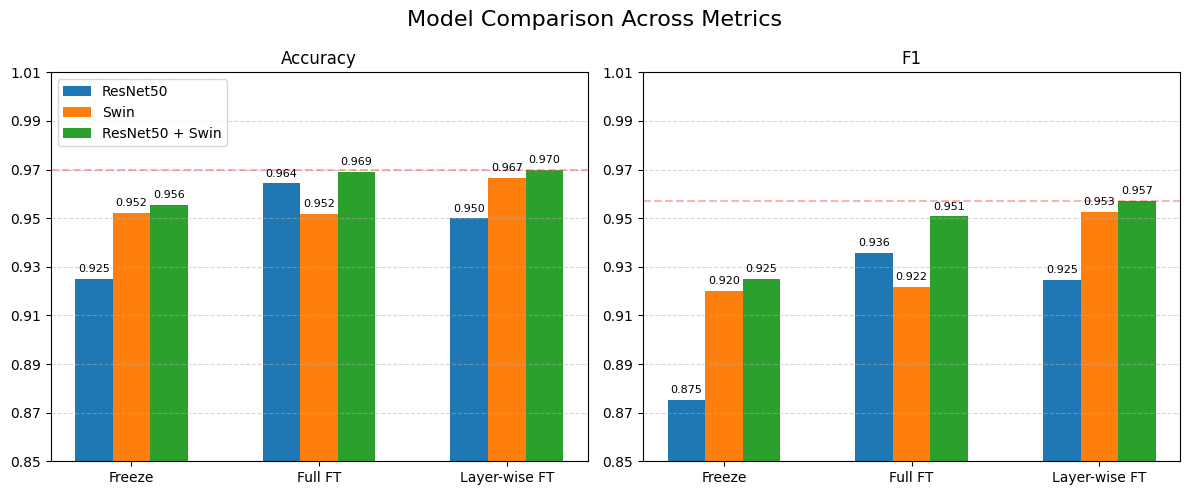

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

metrics = ['Accuracy', 'F1']
strategies = ['Freeze', 'Full FT', 'Layer-wise FT']
models = ['ResNet50', 'Swin', 'ResNet50 + Swin']

colors = ['#1f77b4', '#ff7f0e', '#2ca02c']  # blue, orange, green

# Data
data = {
    'Freeze': [
        [0.9251, 0.8751],
        [0.9522, 0.9202],
        [0.9556, 0.9250]
    ],
    'Full FT': [
        [0.9643, 0.9356],
        [0.9516, 0.9216],
        [0.9689, 0.9507]
    ],
    'Layer-wise FT': [
        [0.9499, 0.9246],
        [0.9666, 0.9525],
        [0.9700, 0.9572]
    ]
}

# Tăng figsize cho rõ ràng
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes = axes.flatten()

width = 0.2
x = np.arange(len(strategies))

for m_idx, metric in enumerate(metrics):
    ax = axes[m_idx]

    all_values = []

    for i in range(len(models)):  # models
        # values cho model i qua các strategies
        values = [data[s][i][m_idx] for s in strategies]
        all_values.extend(values)

        # offset để bars căn giữa nhóm
        offset = (i - 1) * width  # vì 3 bars: -width, 0, +width
        bars = ax.bar(x + offset, values, width,
                      label=models[i], color=colors[i])

        # ghi giá trị lên bar
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2, height + 0.002,
                    f'{height:.3f}', ha='center', va='bottom', fontsize=8)

    max_val = max(all_values)
    ax.axhline(max_val, linestyle='--', alpha=0.3, color='red')

    ax.set_title(metric, fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels(strategies, fontsize=10)

    ax.set_ylim(0.85, 1.0)
    ax.set_yticks(np.arange(0.85, 1.01, 0.02))
    ax.tick_params(axis='y', labelsize=10)

    ax.grid(axis='y', linestyle='--', alpha=0.5)

axes[0].legend(loc='upper left', fontsize=10)
plt.suptitle('Model Comparison Across Metrics', fontsize=16)
plt.tight_layout()
plt.show()

Nhận xét về hiệu quả các kỹ thuật tuning:

- Chiến lược Freeze (chỉ fine-tune lớp cuối) cho kết quả thấp nhất về Accuracy và F1-score, cho thấy giữ nguyên hầu hết trọng số pre-trained không đủ để mô hình thích nghi với dataset mới, đặc biệt khi dữ liệu khác phân bố so với ImageNet.
- Full Fine-Tuning cải thiện đáng kể hiệu suất trên cả 3 mô hình so với Freeze, vì cập nhật toàn bộ trọng số giúp học đặc trưng phù hợp nhiệm vụ.
- Layer-wise Fine-Tuning thường đạt hiệu suất cao nhất, đặc biệt với ResNet50 + Swin, nhờ cân bằng giữa bảo tồn kiến thức pre-trained và thích nghi dữ liệu mới, hạn chế overfitting.

Ảnh hưởng kiến trúc mô hình:

- ResNet50 khi freeze hạn chế khả năng trích xuất đặc trưng so với Swin, nhưng full/layer-wise FT cải thiện rõ rệt.
- ResNet50 + Swin luôn đạt hiệu suất cao nhất, layer-wise FT khai thác tốt cả đặc trưng cục bộ (CNN) và global (Transformer).

Tổng quan:

- Layer-wise Fine-Tuning hiệu quả nhất về cân bằng giữa kiến thức pre-trained và tối ưu dataset.
- Full Fine-Tuning gần bằng layer-wise nhưng rủi ro overfitting cao hơn, nhất là dữ liệu nhỏ.
- Freeze tiết kiệm thời gian huấn luyện nhưng hiệu suất hạn chế.

**Efficiency Comparison**

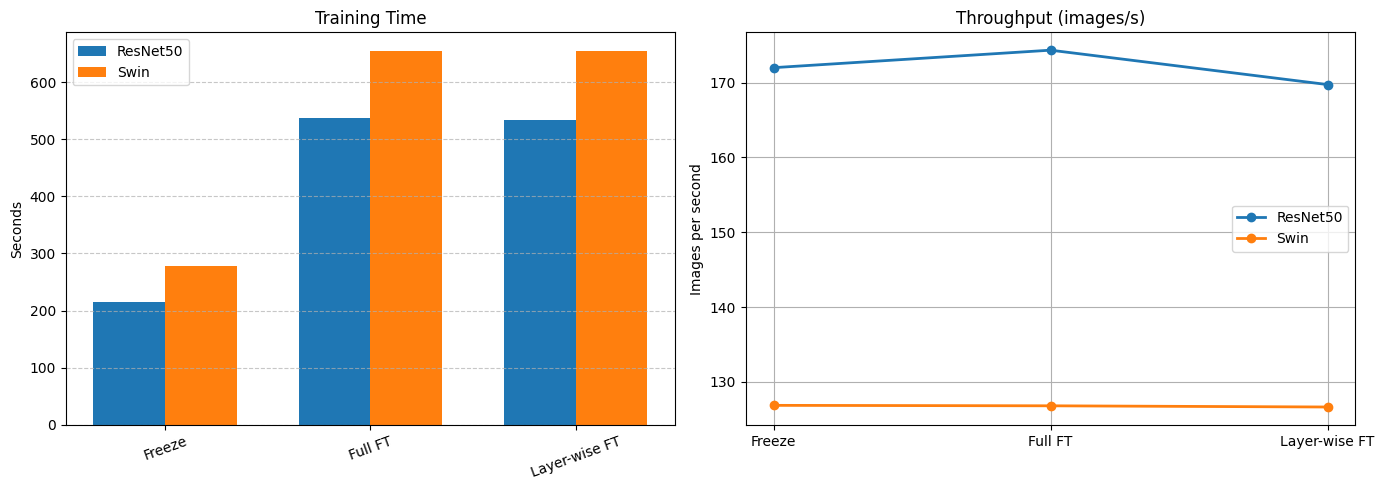

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Labels
methods = ['Freeze', 'Full FT', 'Layer-wise FT']
x = np.arange(len(methods))
width = 0.35

# ===== DATA =====
resnet_train = [214.27, 537.69, 533.41]
swin_train   = [278.10, 654.22, 654.06]

resnet_thr = [172.01, 174.35, 169.75]
swin_thr   = [126.85, 126.79, 126.63]

# ===== PLOT: 2 plots in 1 row =====
fig, axs = plt.subplots(1, 2, figsize=(14,5))

# --- Training Time ---
axs[0].bar(x - width/2, resnet_train, width, label='ResNet50')
axs[0].bar(x + width/2, swin_train, width, label='Swin')
axs[0].set_xticks(x)
axs[0].set_xticklabels(methods, rotation=20)
axs[0].set_ylabel('Seconds')
axs[0].set_title('Training Time')
axs[0].grid(axis='y', linestyle='--', alpha=0.7)
axs[0].legend()

# --- Throughput ---
axs[1].plot(methods, resnet_thr, marker='o', linewidth=2, label='ResNet50')
axs[1].plot(methods, swin_thr, marker='o', linewidth=2, label='Swin')
axs[1].set_title('Throughput (images/s)')
axs[1].set_ylabel('Images per second')
axs[1].grid(True)
axs[1].legend()

plt.tight_layout()
plt.show()

Nhận xét về hiệu năng:
- Ở cả 3 chiến lượt tuning, ResNet50 đều tiết kiệm thời gian training, cũng như khả năng xử lí trên một đơn vị thòi gian (throughput) hơn so với Swin.

**Robustness strategy effects**

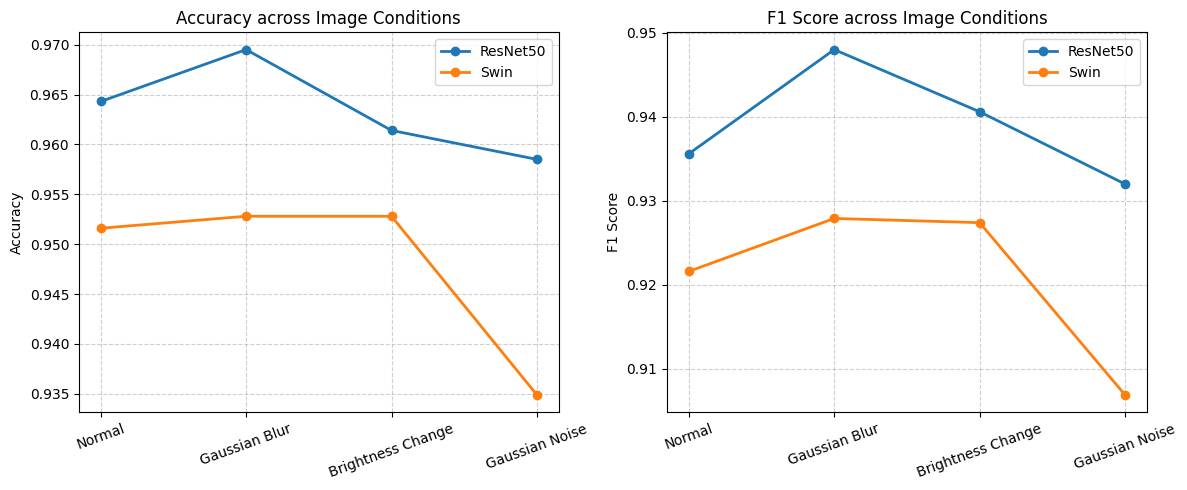

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ===== DATA =====
conditions = ['Normal', 'Gaussian Blur', 'Brightness Change', 'Gaussian Noise']

# Accuracy
resnet_acc = [0.9643, 0.9695, 0.9614, 0.9585]
swin_acc   = [0.9516, 0.9528, 0.9528, 0.9349]

# F1 Score
resnet_f1 = [0.9356, 0.9480, 0.9406, 0.9320]
swin_f1   = [0.9216, 0.9279, 0.9274, 0.9069]

# ===== PLOT =====
fig, axs = plt.subplots(1, 2, figsize=(12,5))

# ---- Accuracy Plot ----
axs[0].plot(conditions, resnet_acc, marker='o', linewidth=2, label='ResNet50')
axs[0].plot(conditions, swin_acc, marker='o', linewidth=2, label='Swin')

axs[0].set_title('Accuracy across Image Conditions')
axs[0].set_ylabel('Accuracy')
axs[0].grid(True, linestyle='--', alpha=0.6)
axs[0].legend()

# ---- F1 Score Plot ----
axs[1].plot(conditions, resnet_f1, marker='o', linewidth=2, label='ResNet50')
axs[1].plot(conditions, swin_f1, marker='o', linewidth=2, label='Swin')

axs[1].set_title('F1 Score across Image Conditions')
axs[1].set_ylabel('F1 Score')
axs[1].grid(True, linestyle='--', alpha=0.6)
axs[1].legend()

# Rotate x labels for readability
for ax in axs:
  ax.set_xticks(np.arange(len(conditions)))
  ax.set_xticklabels(conditions, rotation=20)

plt.tight_layout()
plt.show()

Kết quả thực nghiệm cho thấy các kỹ thuật augmentation có tác động khác nhau đến hiệu năng mô hình:

- **Gaussian Blur**: Giúp cải thiện tốt cho cả Accuracy và F1-score ở cả hai mô hình → cho thấy hiệu quả trong việc hỗ trợ khả năng tổng quát hóa.

- **Brightness Change**: Mang lại cải thiện ở mức trung bình và khá ổn định → mô hình thích nghi tốt với biến đổi độ sáng.


- **Gaussian Noise**: Làm giảm hiệu năng rõ rệt, đặc biệt với Swin → cho thấy augmentation này (ở thiết lập hiện tại) gây ảnh hưởng tiêu cực.

Kết luận:
Gaussian Blur và Brightness Change có lợi cho huấn luyện, trong khi - Gaussian Noise không phù hợp trong cấu hình này.

## **6. Kết luận tổng hợp**

Kết quả thực nghiệm cho thấy hiệu năng mô hình phụ thuộc mạnh vào cả chiến lược fine-tuning, kiến trúc mô hình và kỹ thuật augmentation. Trong đó, Layer-wise Fine-Tuning là phương pháp hiệu quả nhất, giúp cân bằng giữa việc tận dụng kiến thức pre-trained và thích nghi với dữ liệu mới, đồng thời hạn chế overfitting tốt hơn so với Full Fine-Tuning.

Về kiến trúc, mô hình kết hợp ResNet50 + Swin Transformer đạt hiệu suất cao nhất nhờ khai thác đồng thời đặc trưng cục bộ và toàn cục. Tuy nhiên, ResNet50 đơn lẻ vẫn là lựa chọn hợp lý trong các bài toán yêu cầu tốc độ, do có thời gian huấn luyện nhanh và throughput cao hơn so với Swin.

Phân tích confusion matrix cho thấy các lỗi chủ yếu xuất hiện ở các lớp có đặc trưng thị giác tương đồng (như water_lily và lotus), cho thấy hạn chế chung của cả hai mô hình trong việc phân biệt các lớp gần nhau.

Cuối cùng, về augmentation, Gaussian Blur và Brightness Change giúp cải thiện khả năng tổng quát hóa, trong khi Gaussian Noise làm giảm hiệu năng, đặc biệt với Swin Transformer.